In [ ]:
import urllib.request
from pathlib import Path

url = "https://data.cms.gov/sites/default/files/2026-05/b5ebab5a-f490-418a-9bce-4b9f31419356/PHY_R26_P05_V10_D24_Prov_Svc.csv" # pulled from data.cms.gov/data.json 
out = Path("data/raw/mpos24.csv")
out.parent.mkdir(parents=True, exist_ok=True)

if not out.exists():
   urllib.request.urlretrieve(url, out)

In [ ]:
import marimo as mo, pandas as pd, numpy as np, sklearn, matplotlib, seaborn as sns
path = "data/raw/mpos24.csv"

Goal: Preprocess and visualize data, with features that make the dataset most workable for IsolationForest.

['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Bene_Day_Srvcs', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt']


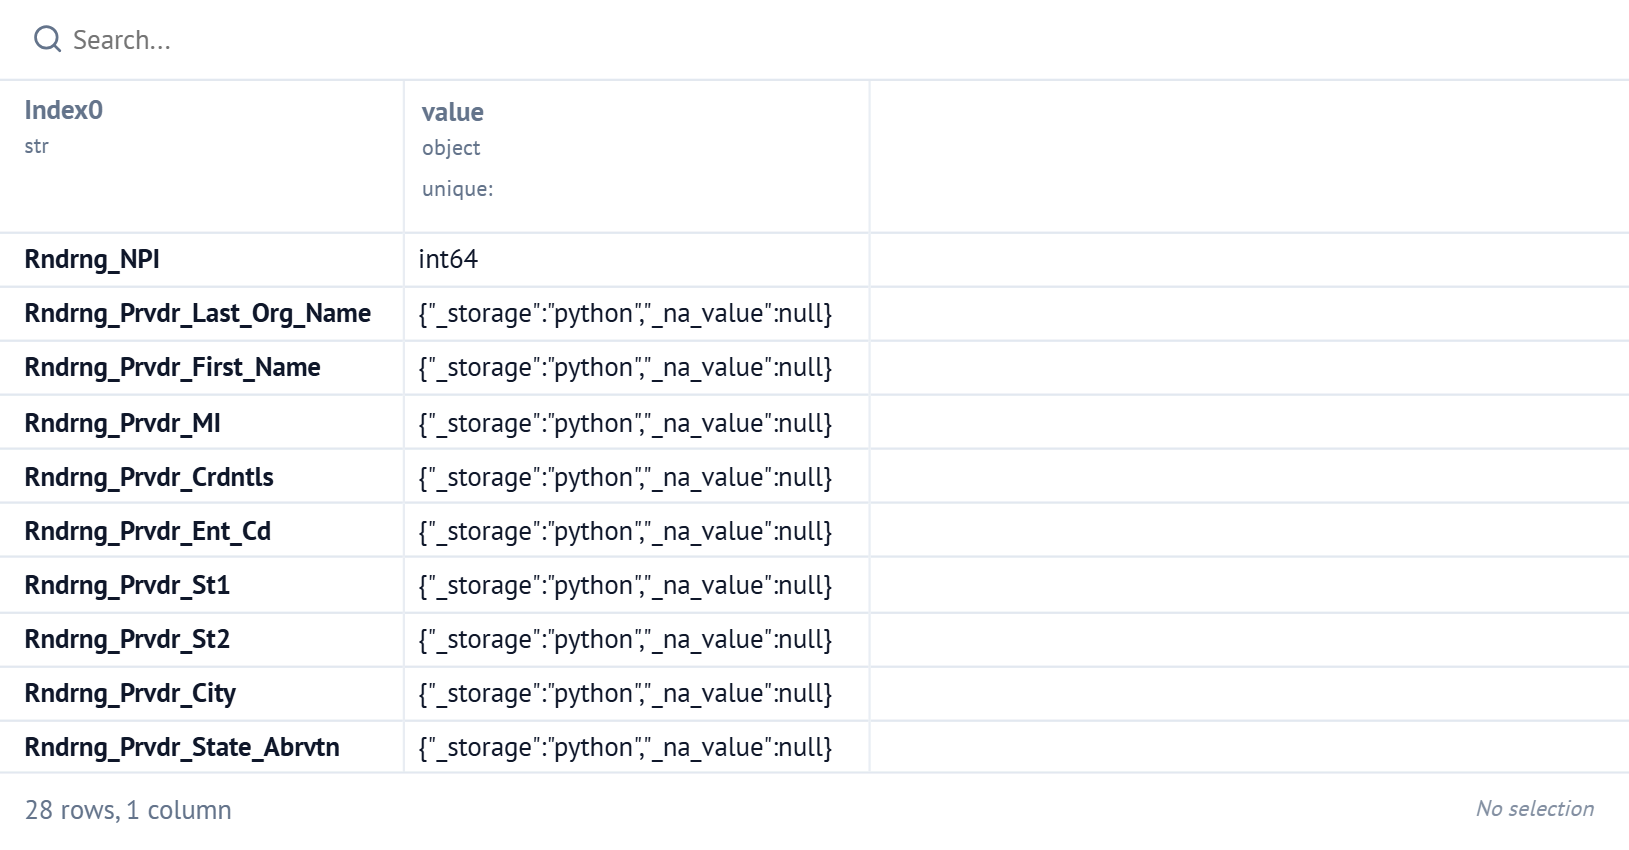

In [ ]:
sample = pd.read_csv(path, nrows=1000) # confirm variables
print(sample.columns.tolist())
sample.dtypes # must check data types to know what to fix/downcast

In [ ]:
usecols = ['Rndrng_NPI','Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc', 'HCPCS_Drug_Ind',  'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Bene_Day_Srvcs', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt',  'Avg_Mdcr_Stdzd_Amt'] # columns selected for use throughout
model_input = ['Tot_Benes', 'Tot_Srvcs', 'Avg_Sbmtd_Chrg',  'Avg_Mdcr_Stdzd_Amt'] # specific features for model input, adjusted after running corr() below.

In [ ]:
mpos24 = pd.read_csv(path, usecols=usecols)
mpos24.shape # 20 features, 9781673 rows

In [ ]:
mpos24.duplicated(subset=['Rndrng_NPI','HCPCS_Cd','Place_Of_Srvc']).sum() # check: one row per provider, service (no duplicates)

In [ ]:
print("dtypes:\n", mpos24[model_input].dtypes) # discovered marimo doesn't need explicit helper calls
print("\nmissing per column:\n", mpos24[model_input].isna().sum())
mpos24[model_input].describe(percentiles=[0.5, 0.9, 0.99]).round(1) # check skew

In [ ]:
mpos24[model_input].corr() # Avg_Mdcr_Alowd_Amt, Avg_Mdcr_Pymt_Amt, Avg_Mdcr_Stdzd_Amt are nigh perfectly correllated, so all three are not valuable inputs to Iso Forest. Same goes for Tot_Benes and Tot_Bene_Day_Srvcs.

In [ ]:
# ratio columns for final feature set
df = mpos24.copy()